# 01 - Data Understanding and Preprocessing for Multivariate Financial and Cryptocurrency Time Series

## Description

This notebook performs the initial data exploration, cleaning, and integration of multiple financial and cryptocurrency time series datasets. The datasets include Bitcoin, Ethereum, Binance Coin, XRP, S&P 500, Dow Jones Industrial Average, and gold (XAU/USD).

The objective is to construct a unified and consistent multivariate dataset aligned by date, which will serve as the foundation for subsequent correlation analysis and deep learning modeling.

The preprocessing pipeline includes:
- Standardization of column names
- Datetime conversion and alignment
- Handling missing values
- Selection of relevant variables
- Feature engineering based on price dynamics

In addition to closing prices, both opening and closing prices are considered to capture intraday behavior. Daily returns are computed using closing prices, as well as optional intraday returns (open-to-close), providing richer information about market dynamics.

The resulting dataset will be used for:
- Temporal correlation analysis (Pearson, Spearman, lagged, and rolling correlations)
- Deep learning models (1D CNN, LSTM, GRU)
- Comparative experiments using different feature configurations (traditional markets, crypto markets, and combined)

# 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Load datasets

In [2]:
# Crypto
btc = pd.read_csv("../data/raw/coin_Bitcoin.csv")

eth = pd.read_csv("../data/raw/coin_Ethereum.csv")
bnb = pd.read_csv("../data/raw/coin_BinanceCoin.csv")
xrp = pd.read_csv("../data/raw/coin_XRP.csv")

# Traditional markets
sp500 = pd.read_csv("../data/raw/SP500.csv")
djia = pd.read_csv("../data/raw/DJIA.csv")
gold = pd.read_csv("../data/raw/XAU_1d_data.csv", sep=";")

# 3. Basic inspection

In [3]:
datasets = {
    "BTC": btc,
    "ETH": eth,
    "BNB": bnb,
    "XRP": xrp,
    "SP500": sp500,
    "DJIA": djia,
    "Gold": gold
}

for name, df in datasets.items():
    print(f"\n{name} INFO:")
    print(df.info())
    print(df.head())
    print("="*50)


BTC INFO:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2991 entries, 0 to 2990
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   SNo        2991 non-null   int64  
 1   Name       2991 non-null   object 
 2   Symbol     2991 non-null   object 
 3   Date       2991 non-null   object 
 4   High       2991 non-null   float64
 5   Low        2991 non-null   float64
 6   Open       2991 non-null   float64
 7   Close      2991 non-null   float64
 8   Volume     2991 non-null   float64
 9   Marketcap  2991 non-null   float64
dtypes: float64(6), int64(1), object(3)
memory usage: 233.8+ KB
None
   SNo     Name Symbol                 Date        High         Low  \
0    1  Bitcoin    BTC  2013-04-29 23:59:59  147.488007  134.000000   
1    2  Bitcoin    BTC  2013-04-30 23:59:59  146.929993  134.050003   
2    3  Bitcoin    BTC  2013-05-01 23:59:59  139.889999  107.720001   
3    4  Bitcoin    BTC  2013-05-02 23:59:59  125.

# 4. Standardize column names

In [4]:
for df in datasets.values():
    df.columns = df.columns.str.lower()

# 5. Columns and data cleaning

In [5]:
def clean_crypto(df, prefix):
    df = df.copy()
    
    # lowercase columns
    df.columns = df.columns.str.lower()
    
    # convert date
    df["date"] = pd.to_datetime(df["date"]).dt.normalize()
    
    # select columns
    df = df[["date", "open", "close"]]
    
    # rename
    df.rename(columns={
        "open": f"{prefix}_open",
        "close": f"{prefix}_close"
    }, inplace=True)
    
    return df

btc = clean_crypto(btc, "btc")
eth = clean_crypto(eth, "eth")
bnb = clean_crypto(bnb, "bnb")
xrp = clean_crypto(xrp, "xrp")


# clean SP500 and DJIA
sp500.columns = sp500.columns.str.lower()
djia.columns = djia.columns.str.lower()

sp500.rename(columns={"observation_date": "date"}, inplace=True)
djia.rename(columns={"observation_date": "date"}, inplace=True)

sp500["date"] = pd.to_datetime(sp500["date"])
djia["date"] = pd.to_datetime(djia["date"])

sp500 = sp500[["date", "sp500"]]
djia = djia[["date", "djia"]]

# clean gold
gold.columns = gold.columns.str.lower()

gold["date"] = pd.to_datetime(gold["date"])

gold = gold[["date", "close"]]
gold = gold.copy()
gold.rename(columns={"close": "gold_close"}, inplace=True)

# 6. Merge datasets

In [6]:
print("Date ranges:")
print("BTC:", btc["date"].min())
print("ETH:", eth["date"].min())
print("BNB:", bnb["date"].min())
print("XRP:", xrp["date"].min())
print("SP500:", sp500["date"].min())
print("Gold:", gold["date"].min())

print("\nLatest dates:")
print("BTC:", btc["date"].max())
print("ETH:", eth["date"].max())
print("BNB:", bnb["date"].max())
print("XRP:", xrp["date"].max())
print("SP500:", sp500["date"].max())
print("Gold:", gold["date"].max())



df = btc.merge(eth, on="date", how="inner")
df = df.merge(bnb, on="date", how="inner")
df = df.merge(xrp, on="date", how="inner")

df = df.merge(sp500, on="date", how="inner")
df = df.merge(djia, on="date", how="inner")
df = df.merge(gold, on="date", how="inner")

df = df.sort_values("date").reset_index(drop=True)

print("\nFinal dataset shape:")
print(df.shape)
df.head()

Date ranges:
BTC: 2013-04-29 00:00:00
ETH: 2015-08-08 00:00:00
BNB: 2017-07-26 00:00:00
XRP: 2013-08-05 00:00:00
SP500: 2016-03-31 00:00:00
Gold: 2004-06-11 00:00:00

Latest dates:
BTC: 2021-07-06 00:00:00
ETH: 2021-07-06 00:00:00
BNB: 2021-07-06 00:00:00
XRP: 2021-07-06 00:00:00
SP500: 2026-03-30 00:00:00
Gold: 2025-12-31 00:00:00

Final dataset shape:
(1018, 12)


,date,btc_open,btc_close,eth_open,eth_close,bnb_open,bnb_close,xrp_open,xrp_close,sp500,djia,gold_close
0,2017-07-26,2577.770020,2529.449951,207.085999,203.953003,0.105893,0.105138,0.177582,0.173822,2477.83,21711.01,1260.84
1,2017-07-27,2538.709961,2671.780029,204.856003,204.317993,0.105108,0.107737,0.175210,0.173457,2475.42,21796.55,1258.42
2,2017-07-28,2679.729980,2809.010010,204.324997,193.123001,0.107632,0.104067,0.173211,0.165937,2472.10,21830.31,1268.91
3,2017-07-31,2763.239990,2875.340088,197.404999,203.871002,0.106828,0.104250,0.165050,0.167386,2470.30,21891.12,1269.37
4,2017-08-01,2871.300049,2718.260010,204.688004,226.768997,0.104595,0.099867,0.168024,0.177053,2476.35,21963.92,1268.92


# 7. Handle missing values

In [7]:
print(df.isnull().sum())

df = df.dropna().copy()

print(df.shape)

date           0
btc_open       0
btc_close      0
eth_open       0
eth_close      0
bnb_open       0
bnb_close      0
xrp_open       0
xrp_close      0
sp500         25
djia          25
gold_close     0
dtype: int64
(993, 12)


# 8. Feature Engineering

In [8]:
df = df.sort_values("date").reset_index(drop=True)

df["btc_return"] = df["btc_close"].pct_change()
df["eth_return"] = df["eth_close"].pct_change()
df["bnb_return"] = df["bnb_close"].pct_change()
df["xrp_return"] = df["xrp_close"].pct_change()

df["sp500_return"] = df["sp500"].pct_change()
df["dow_return"] = df["djia"].pct_change()
df["gold_return"] = df["gold_close"].pct_change()

# Intraday returns (open - close)

In [9]:
df["btc_intraday"] = (df["btc_close"] - df["btc_open"]) / df["btc_open"]
df["eth_intraday"] = (df["eth_close"] - df["eth_open"]) / df["eth_open"]
df["bnb_intraday"] = (df["bnb_close"] - df["bnb_open"]) / df["bnb_open"]
df["xrp_intraday"] = (df["xrp_close"] - df["xrp_open"]) / df["xrp_open"]

# 9. Clean after returns

In [10]:
df = df.dropna().copy()

# 10. Quick validation

(992, 23)
date            0
btc_open        0
btc_close       0
eth_open        0
eth_close       0
bnb_open        0
bnb_close       0
xrp_open        0
xrp_close       0
sp500           0
djia            0
gold_close      0
btc_return      0
eth_return      0
bnb_return      0
xrp_return      0
sp500_return    0
dow_return      0
gold_return     0
btc_intraday    0
eth_intraday    0
bnb_intraday    0
xrp_intraday    0
dtype: int64


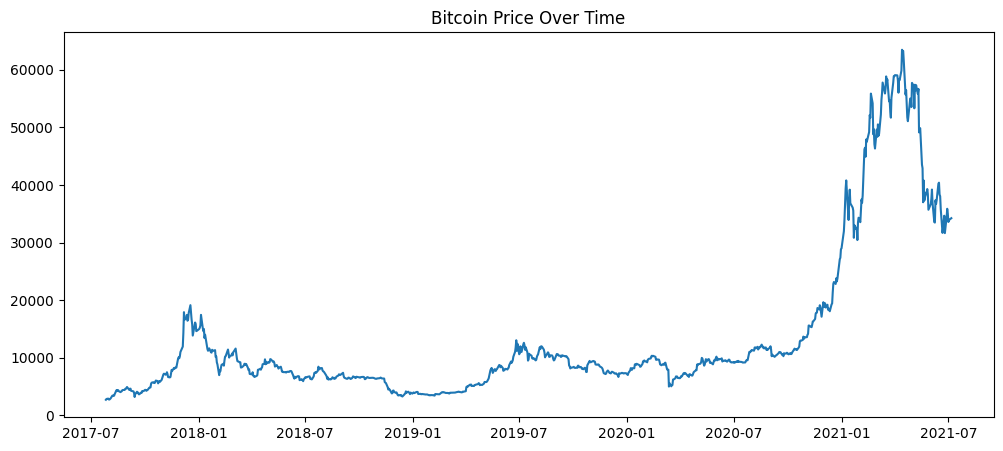

In [11]:
print(df.shape)
print(df.isnull().sum())
df.describe()



plt.figure(figsize=(12,5))
plt.plot(df["date"], df["btc_close"])
plt.title("Bitcoin Price Over Time")
plt.show()

# 11. Save datasets

In [12]:
df.to_csv("../data/generated/processed_full.csv", index=False)

df_returns = df[[
    "date",
    "btc_return",
    "eth_return",
    "bnb_return",
    "xrp_return",
    "sp500_return",
    "dow_return",
    "gold_return",
    "btc_intraday"
]].copy()

df_returns.to_csv("../data/generated/processed_returns.csv", index=False)

## Data Scope Limitation

The analysis is restricted to the period where all assets are simultaneously available, resulting in a dataset from mid-2017 to 2021. This ensures consistency across all variables and avoids introducing bias due to missing data in certain assets.